# **Image Classifier**

Investigate how a useful image-classification model can be progressively optimized for deployment on resource-constrained embedded hardware while maintaining acceptable accuracy.

## Initial Task

Classify images into:

1. Apple
2. Banana
3. Orange

## Development Environment

* Google Colab

## Target Hardware

**AI-Thinker ESP32-CAM**

| Resource       |                       Specification |
| -------------- | ----------------------------------: |
| CPU            | Dual-core Xtensa LX6, up to 240 MHz |
| Flash          |                                4 MB |
| Internal SRAM  |                              520 KB |
| External PSRAM |                                4 MB |
| Wi-Fi          |                        802.11 b/g/n |
| Bluetooth      |                       Bluetooth 4.2 |

## Project Objective

**Find the smallest useful model that satisfies the target hardware constraints while maintaining acceptable classification accuracy.**

## Optimization Dimensions

The experiments will investigate the trade-offs between:

* Accuracy
* Model size
* Flash usage
* RAM usage
* Computational requirements
* Inference latency

# Set the Environmental conditions

In [2]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# Read & Understand the Dataset

## *Upload the Dataset*

In [4]:
import zipfile

zip_path = Path("/content/Fruits_Dataset.zip")
dataset_path = Path("/content/Fruits_Dataset")
with zipfile.ZipFile(zip_path) as z:
  z.extractall("/content")
os.remove(zip_path)
print("Dataset path:", dataset_path)

Dataset path: /content/Fruits_Dataset


## *Verify the file*

In [5]:
from PIL import Image

classes = ["Apple", "Banana", "Orange"]
for split in ["Train", "Validation", "Test"]:
  print(f"\n{split}")
  for class_name in classes:
    folder = Path(dataset_path) / split / class_name
    count = len(list(folder.glob("*.jpg")))
    imagePath = list(folder.glob("*.jpg"))[0]
    image = Image.open(imagePath)
    print(f"{class_name}: {count}, Image Size: {image.size}, Image Mode: {image.mode}")


Train
Apple: 350, Image Size: (100, 100), Image Mode: RGB
Banana: 350, Image Size: (100, 100), Image Mode: RGB
Orange: 350, Image Size: (100, 100), Image Mode: RGB

Validation
Apple: 75, Image Size: (100, 100), Image Mode: RGB
Banana: 75, Image Size: (100, 100), Image Mode: RGB
Orange: 75, Image Size: (100, 100), Image Mode: RGB

Test
Apple: 75, Image Size: (100, 100), Image Mode: RGB
Banana: 75, Image Size: (100, 100), Image Mode: RGB
Orange: 75, Image Size: (100, 100), Image Mode: RGB


# **Baseline Model**

## Create the Model

In [6]:
# design CNN model

SEED = 42
MAX_EPOCHS = 100
BATCH_SIZE = 32
IMG_SIZE = (100, 100)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

model = keras.Sequential([
  layers.Input(shape=(100, 100, 3)),
  layers.Rescaling(1./255),
  layers.Conv2D(16, (3, 3), padding="same", activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
  layers.MaxPooling2D((2, 2)),
  layers.Flatten(),
  layers.Dense(64, activation="relu"),
  layers.Dense(3, activation="softmax")
])

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,285,347 (4.90 MB)

 Trainable params: 1,285,347 (4.90 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])

In [9]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss",
    patience=5, restore_best_weights=True)

In [10]:
def load_image(image_path, label):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_jpeg(image, channels=3)
  image = tf.image.resize(image, [100, 100])
  return image, label

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory("/content/Fruits_Dataset/Train",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=SEED)

val_ds = tf.keras.utils.image_dataset_from_directory("/content/Fruits_Dataset/Validation",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

test_ds = tf.keras.utils.image_dataset_from_directory("/content/Fruits_Dataset/Test",
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

Found 1050 files belonging to 3 classes.
Found 225 files belonging to 3 classes.
Found 225 files belonging to 3 classes.


In [12]:
history = model.fit(train_ds, validation_data=val_ds, epochs=MAX_EPOCHS,
                                                     callbacks=[early_stopping])

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 248ms/step - accuracy: 0.7743 - loss: 0.5212 - val_accuracy: 0.9289 - val_loss: 0.2380
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 272ms/step - accuracy: 0.9610 - loss: 0.1390 - val_accuracy: 0.9689 - val_loss: 0.1151
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 277ms/step - accuracy: 0.9867 - loss: 0.0544 - val_accuracy: 0.9733 - val_loss: 0.0641
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 230ms/step - accuracy: 0.9933 - loss: 0.0286 - val_accuracy: 0.9822 - val_loss: 0.0715
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 243ms/step - accuracy: 0.9962 - loss: 0.0137 - val_accuracy: 0.9822 - val_loss: 0.0496
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 265ms/step - accuracy: 0.9990 - loss: 0.0067 - val_accuracy: 0.9778 - val_loss: 0.0794
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 312ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9867 - val_loss: 0.0589
Epoch 8/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 223ms/step - accuracy: 1.0000 - loss: 0.0013 - val

## Evaluate the Model

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)
print("Epochs actually trained:", len(history.history["loss"]))

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.9911 - loss: 0.0325
Test loss: 0.032481804490089417
Test accuracy: 0.9911110997200012
Epochs actually trained: 10


In [14]:
y_true = []
y_pred = []
for images, labels in test_ds:
  predictions = model.predict(images, verbose=0)
  y_true.extend(labels.numpy())
  y_pred.extend(np.argmax(predictions, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=classes))

[[73  1  1]
 [ 0 75  0]
 [ 0  0 75]]
              precision    recall  f1-score   support

       Apple       1.00      0.97      0.99        75
      Banana       0.99      1.00      0.99        75
      Orange       0.99      1.00      0.99        75

    accuracy                           0.99       225
   macro avg       0.99      0.99      0.99       225
weighted avg       0.99      0.99      0.99       225



## Convert to TFlite

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = "/content/baseline_fp32.tflite"
with open(tflite_path, "wb") as f:
  f.write(tflite_model)
print("TFLite model saved:", tflite_path)

Saved artifact at '/tmp/tmpkn9acon3'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139719129971408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120995728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120997264: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved: /content/baseline_fp32.tflite


In [16]:
size_bytes = os.path.getsize(tflite_path)
size_kb = size_bytes / 1024
size_mb = size_bytes / (1024 * 1024)

print(f"Model size: {size_bytes:,} bytes")
print(f"Model size: {size_kb:.2f} KB")
print(f"Model size: {size_mb:.2f} MB")

Model size: 5,145,440 bytes
Model size: 5024.84 KB
Model size: 4.91 MB


In [17]:
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input:")
print(input_details)

print("\nOutput:")
print(output_details)

Input:
[{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([  1, 100, 100,   3], dtype=int32), 'shape_signature': array([ -1, 100, 100,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]

Output:
[{'name': 'StatefulPartitionedCall_1:0', 'index': 22, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## **Baseline Model Observations**

The baseline model provides a useful starting point for the optimization experiments.

| Metric | Baseline |
|---|---:|
| Parameters | 1,285,347 |
| Weight representation | FP32 |
| Activation representation | FP32 |
| Test accuracy | 99.11% |
| Test errors | 2 / 225 |
| TFLite model size | 4.91 MiB |
| Largest activation tensor | ~625 KiB |

### What did we get?

The model achieves **99.11% test accuracy**, so the classification task itself is working well.

However, the model is not yet suitable for the target hardware.

- The serialized FP32 model is approximately **4.91 MiB**, which already exceeds the nominal **4 MB Flash** capacity before accounting for firmware and other data.
- The largest activation tensor is approximately **625 KiB**, which is larger than the **520 KB internal SRAM** capacity.
- Therefore, the baseline model has both **storage and memory constraints** that need to be addressed.

> **Baseline conclusion:** Accuracy is acceptable, but the model's resource requirements are not yet suitable for the target embedded system.

# Optimization Model 1 - FP16

## Investigate whether reducing the numerical precision of the model's stored weights can reduce Flash usage without retraining the model.

## Convert TFlite to FP 16

In [18]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

fp16_tflite_model = converter.convert()
fp16_path = "/content/baseline_fp16.tflite"
with open(fp16_path, "wb") as f:
  f.write(fp16_tflite_model)
print("FP16 model saved:", fp16_path)

Saved artifact at '/tmp/tmp_b95ho25'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139719129971408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120995728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120997264: TensorSpec(shape=(), dtype=tf.resource, name=None)
FP16 model saved: /content/baseline_fp16.tflite


In [19]:
size_bytes = os.path.getsize(fp16_path)
size_kb = size_bytes / 1024
size_mb = size_bytes / (1024 * 1024)

print(f"FP16 model size: {size_bytes:,} bytes")
print(f"FP16 model size: {size_kb:.2f} KB")
print(f"FP16 model size: {size_mb:.2f} MB")

FP16 model size: 2,575,676 bytes
FP16 model size: 2515.31 KB
FP16 model size: 2.46 MB


In [20]:
interpreter_fp16 = tf.lite.Interpreter(model_path=fp16_path)
interpreter_fp16.allocate_tensors()

input_details = interpreter_fp16.get_input_details()
output_details = interpreter_fp16.get_output_details()

print("FP16 TFLite Model")
print("-" * 40)

print("Input:")
print("  Shape :", input_details[0]["shape"])
print("  Dtype :", input_details[0]["dtype"])

print("\nOutput:")
print("  Shape :", output_details[0]["shape"])
print("  Dtype :", output_details[0]["dtype"])

FP16 TFLite Model
----------------------------------------
Input:
  Shape : [  1 100 100   3]
  Dtype : <class 'numpy.float32'>

Output:
  Shape : [1 3]
  Dtype : <class 'numpy.float32'>


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Evaluate the Model

In [21]:
y_true = []
y_pred_fp16 = []
for images, labels in test_ds:
  images_np = images.numpy()
  labels_np = labels.numpy()
  for i in range(len(images_np)):
    input_data = np.expand_dims(images_np[i], axis=0).astype(np.float32)
    interpreter_fp16.set_tensor(input_details[0]["index"], input_data)
    interpreter_fp16.invoke()
    output = interpreter_fp16.get_tensor(output_details[0]["index"])
    predicted_class = np.argmax(output[0])
    y_true.append(labels_np[i])
    y_pred_fp16.append(predicted_class)
y_true = np.array(y_true)
y_pred_fp16 = np.array(y_pred_fp16)
accuracy_fp16 = accuracy_score(y_true, y_pred_fp16)
print(f"FP16 Test Accuracy: {accuracy_fp16 * 100:.2f}%")
cm_fp16 = confusion_matrix(y_true, y_pred_fp16)
print("\nConfusion Matrix:")
print(cm_fp16)
print("\nClassification Report:")
print(classification_report(y_true, y_pred_fp16, target_names=test_ds.class_names))

FP16 Test Accuracy: 99.11%

Confusion Matrix:
[[73  1  1]
 [ 0 75  0]
 [ 0  0 75]]

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      0.97      0.99        75
      Banana       0.99      1.00      0.99        75
      Orange       0.99      1.00      0.99        75

    accuracy                           0.99       225
   macro avg       0.99      0.99      0.99       225
weighted avg       0.99      0.99      0.99       225



## Investigate Activation Representation

In [22]:
interpreter_fp16_full = tf.lite.Interpreter(model_path=fp16_path)
interpreter_fp16_full.allocate_tensors()

print("Internal Tensor Dtypes")
print("-" * 60)

for tensor in interpreter_fp16_full.get_tensor_details():
  print(f"Name: {tensor['name']:<45} "f"Dtype: {tensor['dtype']}")

Internal Tensor Dtypes
------------------------------------------------------------
Name: serving_default_keras_tensor:0                Dtype: <class 'numpy.float32'>
Name: arith.constant                                Dtype: <class 'numpy.float16'>
Name: arith.constant1                               Dtype: <class 'numpy.int32'>
Name: arith.constant2                               Dtype: <class 'numpy.int32'>
Name: arith.constant3                               Dtype: <class 'numpy.int32'>
Name: arith.constant4                               Dtype: <class 'numpy.float16'>
Name: arith.constant5                               Dtype: <class 'numpy.float16'>
Name: arith.constant6                               Dtype: <class 'numpy.float16'>
Name: arith.constant7                               Dtype: <class 'numpy.float16'>
Name: arith.constant8                               Dtype: <class 'numpy.float16'>
Name: arith.constant9                               Dtype: <class 'numpy.float16'>
Name: ari

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Optimization Model 1 - FP 16 Observations

The FP16 conversion reduces the serialized model size from **4.91 MiB to 2.46 MiB**, while maintaining the same observed test accuracy of **99.11%**.

| Metric | Baseline FP32 | FP16 |
|---|---:|---:|
| Parameters | 1,285,347 | 1,285,347 |
| Weight representation | FP32 | FP16 |
| Activation representation | FP32 | FP32 |
| Test accuracy | 99.11% | 99.11% |
| Test errors | 2 / 225 | 2 / 225 |
| TFLite model size | 4.91 MiB | 2.46 MiB |
| Largest activation | ~625 KiB | ~625 KiB |

### What changed?

The learned model and number of parameters remain unchanged.

The main change is the representation of the stored weights:

**FP32 → FP16**

This reduces the model's serialized size by approximately **50%**.

The test predictions also remain unchanged for all 225 test images.

### What did not change?

Inspection of the internal TFLite tensors shows that the major activation tensors remain **FP32**.

Therefore, although FP16 reduces the model's storage requirement, it does not reduce the activation-memory requirement in this conversion path.

The largest activation remains approximately **625 KiB**.

### What does this mean?

FP16 successfully addresses part of the Flash constraint, but it does not address the activation-memory constraint.

> **FP16 conclusion:** Weight storage was reduced substantially without observed accuracy loss, but the activation-memory bottleneck remains.

# Optimization Model 2 - INT8

## Investigate whether full integer quantization can reduce both model storage and activation memory while maintaining classification accuracy.

## Convert TFlite to INT 8

In [23]:
def representative_dataset():
  for images, _ in train_ds.take(100):
    for image in images:
      image = tf.expand_dims(image, axis=0)
      yield [tf.cast(image, tf.float32)]

In [24]:
converter_int8 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_int8.optimizations = [tf.lite.Optimize.DEFAULT]
converter_int8.representative_dataset = representative_dataset
converter_int8.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter_int8.inference_input_type = tf.int8
converter_int8.inference_output_type = tf.int8

int8_tflite_model = converter_int8.convert()
int8_path = "/content/baseline_int8.tflite"
with open(int8_path, "wb") as f:
  f.write(int8_tflite_model)
print("INT8 model saved:", int8_path)

Saved artifact at '/tmp/tmp2g61ihpy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  139719129971408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120995728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120996688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139719120997264: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


INT8 model saved: /content/baseline_int8.tflite


In [25]:
size_bytes = os.path.getsize(int8_path)
size_kb = size_bytes / 1024
size_mb = size_bytes / (1024 * 1024)

print(f"INT8 model size: {size_bytes:,} bytes")
print(f"INT8 model size: {size_kb:.2f} KB")
print(f"INT8 model size: {size_mb:.2f} MB")

INT8 model size: 1,292,912 bytes
INT8 model size: 1262.61 KB
INT8 model size: 1.23 MB


In [26]:
interpreter_int8 = tf.lite.Interpreter(model_path=int8_path)
interpreter_int8.allocate_tensors()

input_details_int8 = interpreter_int8.get_input_details()
output_details_int8 = interpreter_int8.get_output_details()

print("INT8 TFLite Model")
print("-" * 50)

print("Input:")
print("  Shape :", input_details_int8[0]["shape"])
print("  Dtype :", input_details_int8[0]["dtype"])
print("  Scale :", input_details_int8[0]["quantization"][0])
print("  Zero Point :", input_details_int8[0]["quantization"][1])

print("\nOutput:")
print("  Shape :", output_details_int8[0]["shape"])
print("  Dtype :", output_details_int8[0]["dtype"])
print("  Scale :", output_details_int8[0]["quantization"][0])
print("  Zero Point :", output_details_int8[0]["quantization"][1])

INT8 TFLite Model
--------------------------------------------------
Input:
  Shape : [  1 100 100   3]
  Dtype : <class 'numpy.int8'>
  Scale : 1.0
  Zero Point : -128

Output:
  Shape : [1 3]
  Dtype : <class 'numpy.int8'>
  Scale : 0.00390625
  Zero Point : -128


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Investigate Activation Representation

In [27]:
print("\nInternal Tensor Dtypes")
print("-" * 70)

for tensor in interpreter_int8.get_tensor_details():
  print(f"Name: {tensor['name']:<50} "
      f"Dtype: {tensor['dtype']}")


Internal Tensor Dtypes
----------------------------------------------------------------------
Name: serving_default_keras_tensor:0                     Dtype: <class 'numpy.int8'>
Name: arith.constant                                     Dtype: <class 'numpy.int32'>
Name: arith.constant1                                    Dtype: <class 'numpy.int32'>
Name: arith.constant2                                    Dtype: <class 'numpy.int32'>
Name: tfl.pseudo_qconst                                  Dtype: <class 'numpy.int32'>
Name: tfl.pseudo_qconst1                                 Dtype: <class 'numpy.int8'>
Name: tfl.pseudo_qconst2                                 Dtype: <class 'numpy.int32'>
Name: tfl.pseudo_qconst3                                 Dtype: <class 'numpy.int8'>
Name: tfl.pseudo_qconst4                                 Dtype: <class 'numpy.int32'>
Name: tfl.pseudo_qconst5                                 Dtype: <class 'numpy.int8'>
Name: tfl.pseudo_qconst6                         

## Evaluate the Model

In [28]:
y_true_int8 = []
y_pred_int8 = []
input_scale, input_zero_point = input_details_int8[0]["quantization"]
for images, labels in test_ds:
  images_np = images.numpy()
  labels_np = labels.numpy()
  for i in range(len(images_np)):
    image = images_np[i]
    image_int8 = np.round(image / input_scale + input_zero_point).astype(np.int8)
    input_data = np.expand_dims(image_int8, axis=0)
    interpreter_int8.set_tensor(input_details_int8[0]["index"], input_data)
    interpreter_int8.invoke()
    output = interpreter_int8.get_tensor(output_details_int8[0]["index"])
    predicted_class = np.argmax(output[0])
    y_true_int8.append(labels_np[i])
    y_pred_int8.append(predicted_class)

y_true_int8 = np.array(y_true_int8)
y_pred_int8 = np.array(y_pred_int8)
accuracy_int8 = accuracy_score(y_true_int8, y_pred_int8)
print(f"INT8 Test Accuracy: {accuracy_int8 * 100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_int8, y_pred_int8))
print("\nClassification Report:")
print(classification_report(y_true_int8, y_pred_int8, target_names=test_ds.class_names))

INT8 Test Accuracy: 99.11%

Confusion Matrix:
[[73  1  1]
 [ 0 75  0]
 [ 0  0 75]]

Classification Report:
              precision    recall  f1-score   support

       Apple       1.00      0.97      0.99        75
      Banana       0.99      1.00      0.99        75
      Orange       0.99      1.00      0.99        75

    accuracy                           0.99       225
   macro avg       0.99      0.99      0.99       225
weighted avg       0.99      0.99      0.99       225



## Optimization Model 2 - INT 8 Observations

Full INT8 quantization reduces both model storage and the representation size of the major activation tensors while maintaining the same observed test accuracy.

| Metric | Baseline FP32 | FP16 | INT8 |
|---|---:|---:|---:|
| Parameters | 1,285,347 | 1,285,347 | 1,285,347 |
| Weight representation | FP32 | FP16 | INT8 |
| Activation representation | FP32 | FP32 | INT8 |
| Test accuracy | 99.11% | 99.11% | 99.11% |
| Test errors | 2 / 225 | 2 / 225 | 2 / 225 |
| TFLite model size | 4.91 MiB | 2.46 MiB | 1.23 MiB |
| Largest activation | ~625 KiB | ~625 KiB | ~156 KiB |

### What changed?

The model is now represented using **INT8 weights and INT8 activations**, with INT32 used where required for intermediate computations such as accumulators.

This reduces the serialized model size from **4.91 MiB to 1.23 MiB**, approximately a **75% reduction** from the FP32 baseline.

The largest activation tensor is reduced from approximately **625 KiB to 156 KiB**, also a **75% reduction** in tensor representation size.

### What about accuracy?

The INT8 model achieves the same observed **99.11% test accuracy** as the FP32 and FP16 models.

The same **2 out of 225** test images are misclassified, with the same confusion matrix.

For this dataset, calibration, model, and test set, the INT8 conversion therefore introduces **no observed accuracy degradation**.

### What does this mean?

Unlike FP16, INT8 addresses both major model-level resource concerns:

- **Flash:** 1.23 MiB serialized model
- **Activation representation:** ~156 KiB largest activation

At the model/tensor level, the INT8 candidate now fits within the nominal resource limits of the target hardware.

> **INT8 conclusion:** Full integer quantization provides the strongest resource reduction so far, while maintaining the same observed classification accuracy.

# Conclusion

The exploration started with a conventional FP32 image-classification model and progressively investigated lower-precision representations without retraining the model.

The three model representations can be summarized as:

| Model | Flash / Model Size | Largest Activation | Test Accuracy |
|---|---:|---:|---:|
| FP32 | 4.91 MiB | ~625 KiB | 99.11% |
| FP16 | 2.46 MiB | ~625 KiB | 99.11% |
| INT8 | 1.23 MiB | ~156 KiB | 99.11% |

The FP16 experiment reduced model storage by approximately 50%, but the major activation tensors remained FP32.

The INT8 experiment reduced both model storage and the representation size of the major activation tensors by approximately 75%, while maintaining the same observed accuracy on the fixed test set.

## Resource Benchmark Graph

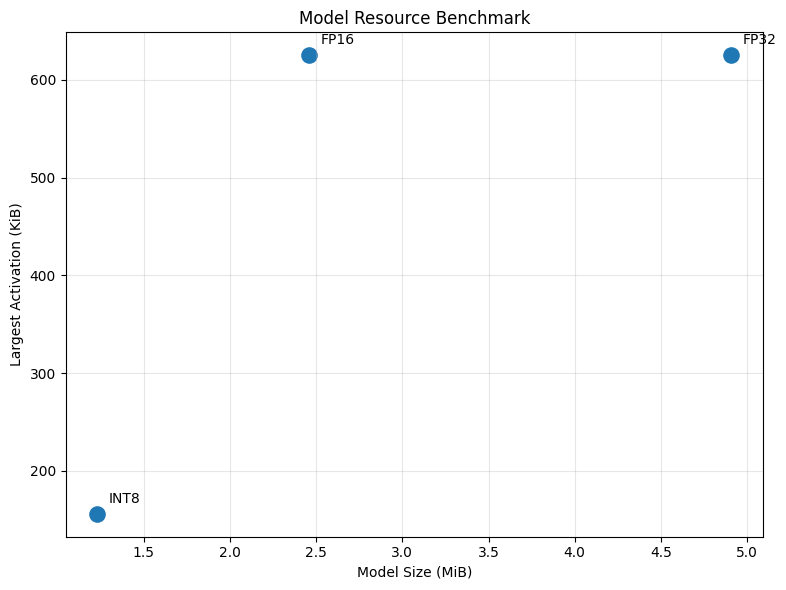

In [29]:
import matplotlib.pyplot as plt

models = ["FP32", "FP16", "INT8"]
model_size_mib = [4.91, 2.46, 1.23]
largest_activation_kib = [625, 625, 156.25]
plt.figure(figsize=(8, 6))
plt.scatter(model_size_mib, largest_activation_kib, s=120)
for model, x, y in zip(models, model_size_mib, largest_activation_kib):
  plt.annotate(model, (x, y), xytext=(8, 8), textcoords="offset points")
plt.xlabel("Model Size (MiB)")
plt.ylabel("Largest Activation (KiB)")
plt.title("Model Resource Benchmark")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()